Empezamos poniendo los import que necesitamos para el programa

In [1]:
# Importar librerías
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import joblib

Llamamos a los datos que vamos a usar

In [2]:
# Dividir en train y test
X_train = pd.read_csv("../Filtrado/X_train.csv")
X_test = pd.read_csv("../Filtrado/X_test.csv")
y_train = pd.read_csv("../Filtrado/y_train.csv")
y_test = pd.read_csv("../Filtrado/y_test.csv")
X_train_scaled = pd.read_csv("../Filtrado/X_train_Escalado.csv")
X_test_scaled = pd.read_csv("../Filtrado/X_test_Escalado.csv")

entrenar el modelo

In [3]:
# IMPORTANTE: No usamos X_train_scaled, usamos X_train directamente
# Los árboles NO necesitan datos estandarizados
arbol_base = DecisionTreeRegressor(random_state=42)
arbol_base.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [4]:
predictors = X_train.columns.tolist()

predictors

['Anio',
 'Marca',
 'Modelo',
 'SubModelo',
 'Condicion',
 'Millas',
 'Color',
 'Interior',
 'MPG',
 'Cilindros',
 'Motor',
 'Traccion',
 'Combustible',
 'Transmision',
 'Tamanio_del_vehiculo']

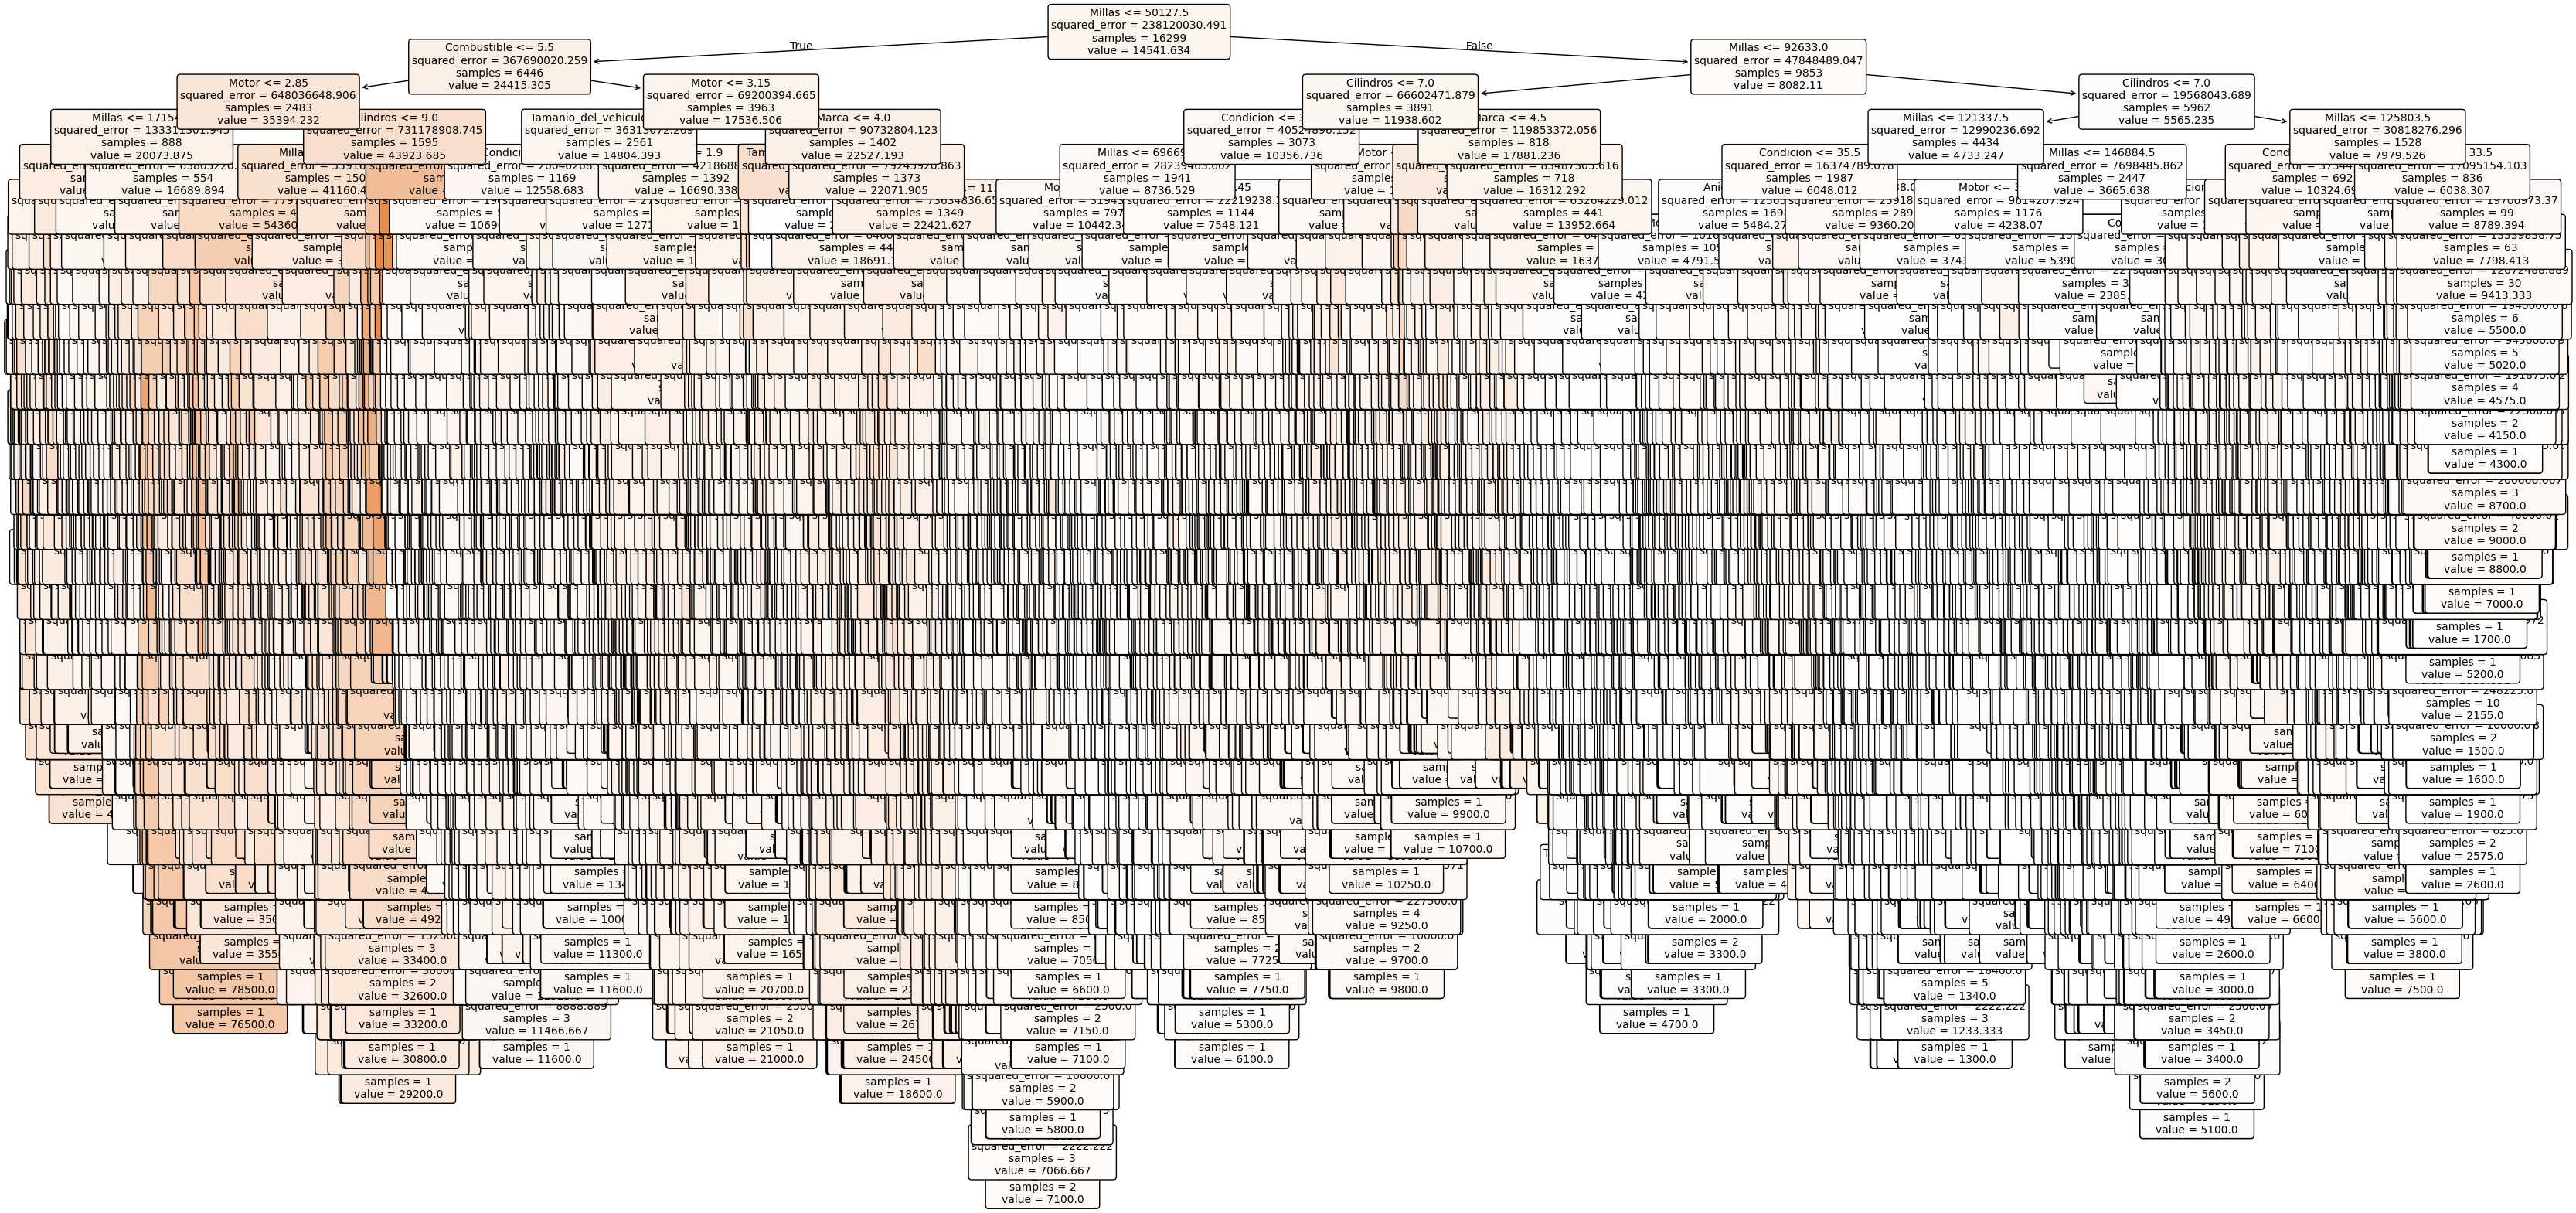

In [5]:
clf = arbol_base  

plt.figure(figsize=(40,20))
plot_tree(
    clf,
    feature_names=predictors,                    
    filled=True, rounded=True, fontsize=10
)
plt.show()

Lo malo es que el arbol es tan grande que cuesta verlo

In [6]:
# Predicciones
y_pred_train_arbol = arbol_base.predict(X_train)
y_pred_test_arbol = arbol_base.predict(X_test)

# Métricas
acc_train_arbol= accuracy_score(y_train, y_pred_train_arbol)
acc_test_arbol = accuracy_score(y_test, y_pred_test_arbol)

In [7]:
print(f"  Profundidad: {arbol_base.get_depth()}")
print(f"  Nº hojas: {arbol_base.get_n_leaves()}")

  Profundidad: 33
  Nº hojas: 15530


In [8]:
print("\nTRAIN:")

print(f"  RMSE:     ${np.sqrt(mean_squared_error(y_train, y_pred_train_arbol)):.2f}")
print(f"  MAE:      ${mean_absolute_error(y_train, y_pred_train_arbol):.2f}")
print(f"  R2:      {r2_score(y_train, y_pred_train_arbol):.2f}")

print("\nTEST:")

print(f"  RMSE:     ${np.sqrt(mean_squared_error(y_test, y_pred_test_arbol)):.2f}")
print(f"  MAE:      ${mean_absolute_error(y_test, y_pred_test_arbol):.2f}")
print(f"  R2:      {r2_score(y_test,  y_pred_test_arbol):.2f}")


TRAIN:
  RMSE:     $0.00
  MAE:      $0.00
  R2:      1.00

TEST:
  RMSE:     $9525.64
  MAE:      $5389.69
  R2:      0.61


                Variable  Importancia
5                 Millas     0.373270
12           Combustible     0.127243
10                 Motor     0.126845
1                  Marca     0.089706
9              Cilindros     0.069419
14  Tamanio_del_vehiculo     0.048002
2                 Modelo     0.042469
3              SubModelo     0.030143
0                   Anio     0.025147
4              Condicion     0.023079
8                    MPG     0.019499
7               Interior     0.008863
6                  Color     0.008206
11              Traccion     0.006541
13           Transmision     0.001568


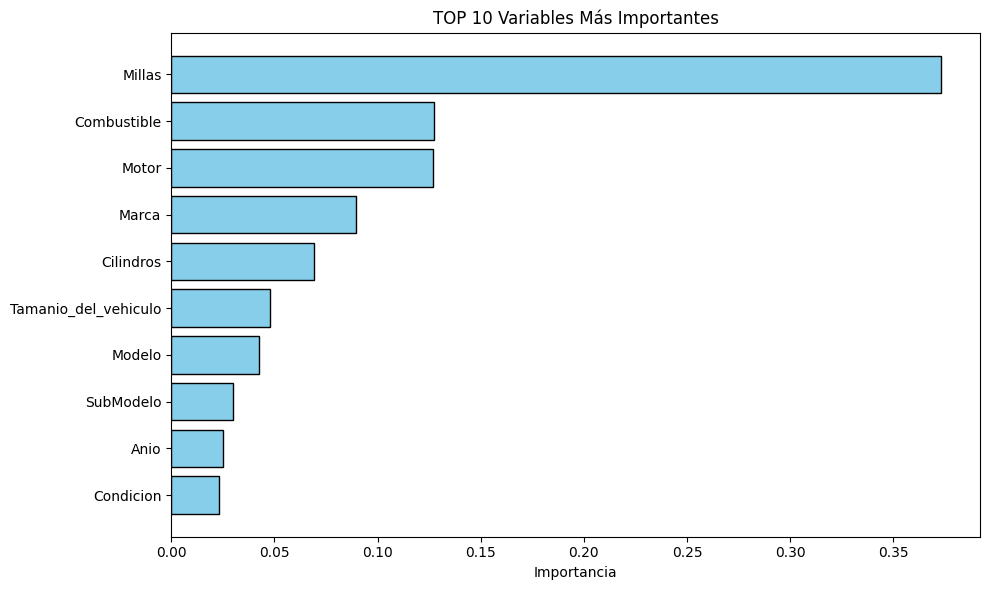

In [9]:
# Importancia de variables
importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': arbol_base.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias)

# Gráfico simple
plt.figure(figsize=(10, 6))
plt.barh(importancias.head(10)['Variable'], 
         importancias.head(10)['Importancia'], 
         color='skyblue', edgecolor='black')
plt.xlabel('Importancia')
plt.title('TOP 10 Variables Más Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Vemos que con diferencia la variable de millas es la mas importante

usamos GridSearchCV para hacer diferentes arboles con diferentes parametros y que seleccione el mejor modelo

In [10]:
# Grid de parámetros
param_grid = {
    'max_depth': [3, 5, 7, 8, 9, 10, 11, 12, 15, 17, 20, 22, 25],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 17, 20],
    'min_samples_leaf': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
}

In [11]:
# GridSearchCV
grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,

    # GridSearchCV siempre busca el número MÁS ALTO. Como el MSE  'menor es mejor' , lo convertimos a negativo para que funcione. -100 es mayor que -500,
    scoring='neg_mean_squared_error',  # Minimiza MSE - Mide cuánto se equivoca el modelo en sus predicciones
    n_jobs=-1,
    verbose=1
)

In [12]:
print("\n Buscando mejores parámetros...\n")
grid.fit(X_train, y_train)


 Buscando mejores parámetros...

Fitting 5 folds for each of 2730 candidates, totalling 13650 fits


,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [2, 3, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [13]:
for param, valor in grid.best_params_.items():
    print(f"  • {param}: {valor}")

print(f"\n Mejor score (MSE): {grid.best_score_:.4f}")

  • max_depth: 12
  • min_samples_leaf: 10
  • min_samples_split: 2

 Mejor score (MSE): -53813431.8072


sacamos la mejor combinacion para sacar el mejor modelo

In [14]:
# Modelo optimizado. El modelo con el MENOR MSE (o mayor neg_MSE)
mejor_modelo = grid.best_estimator_

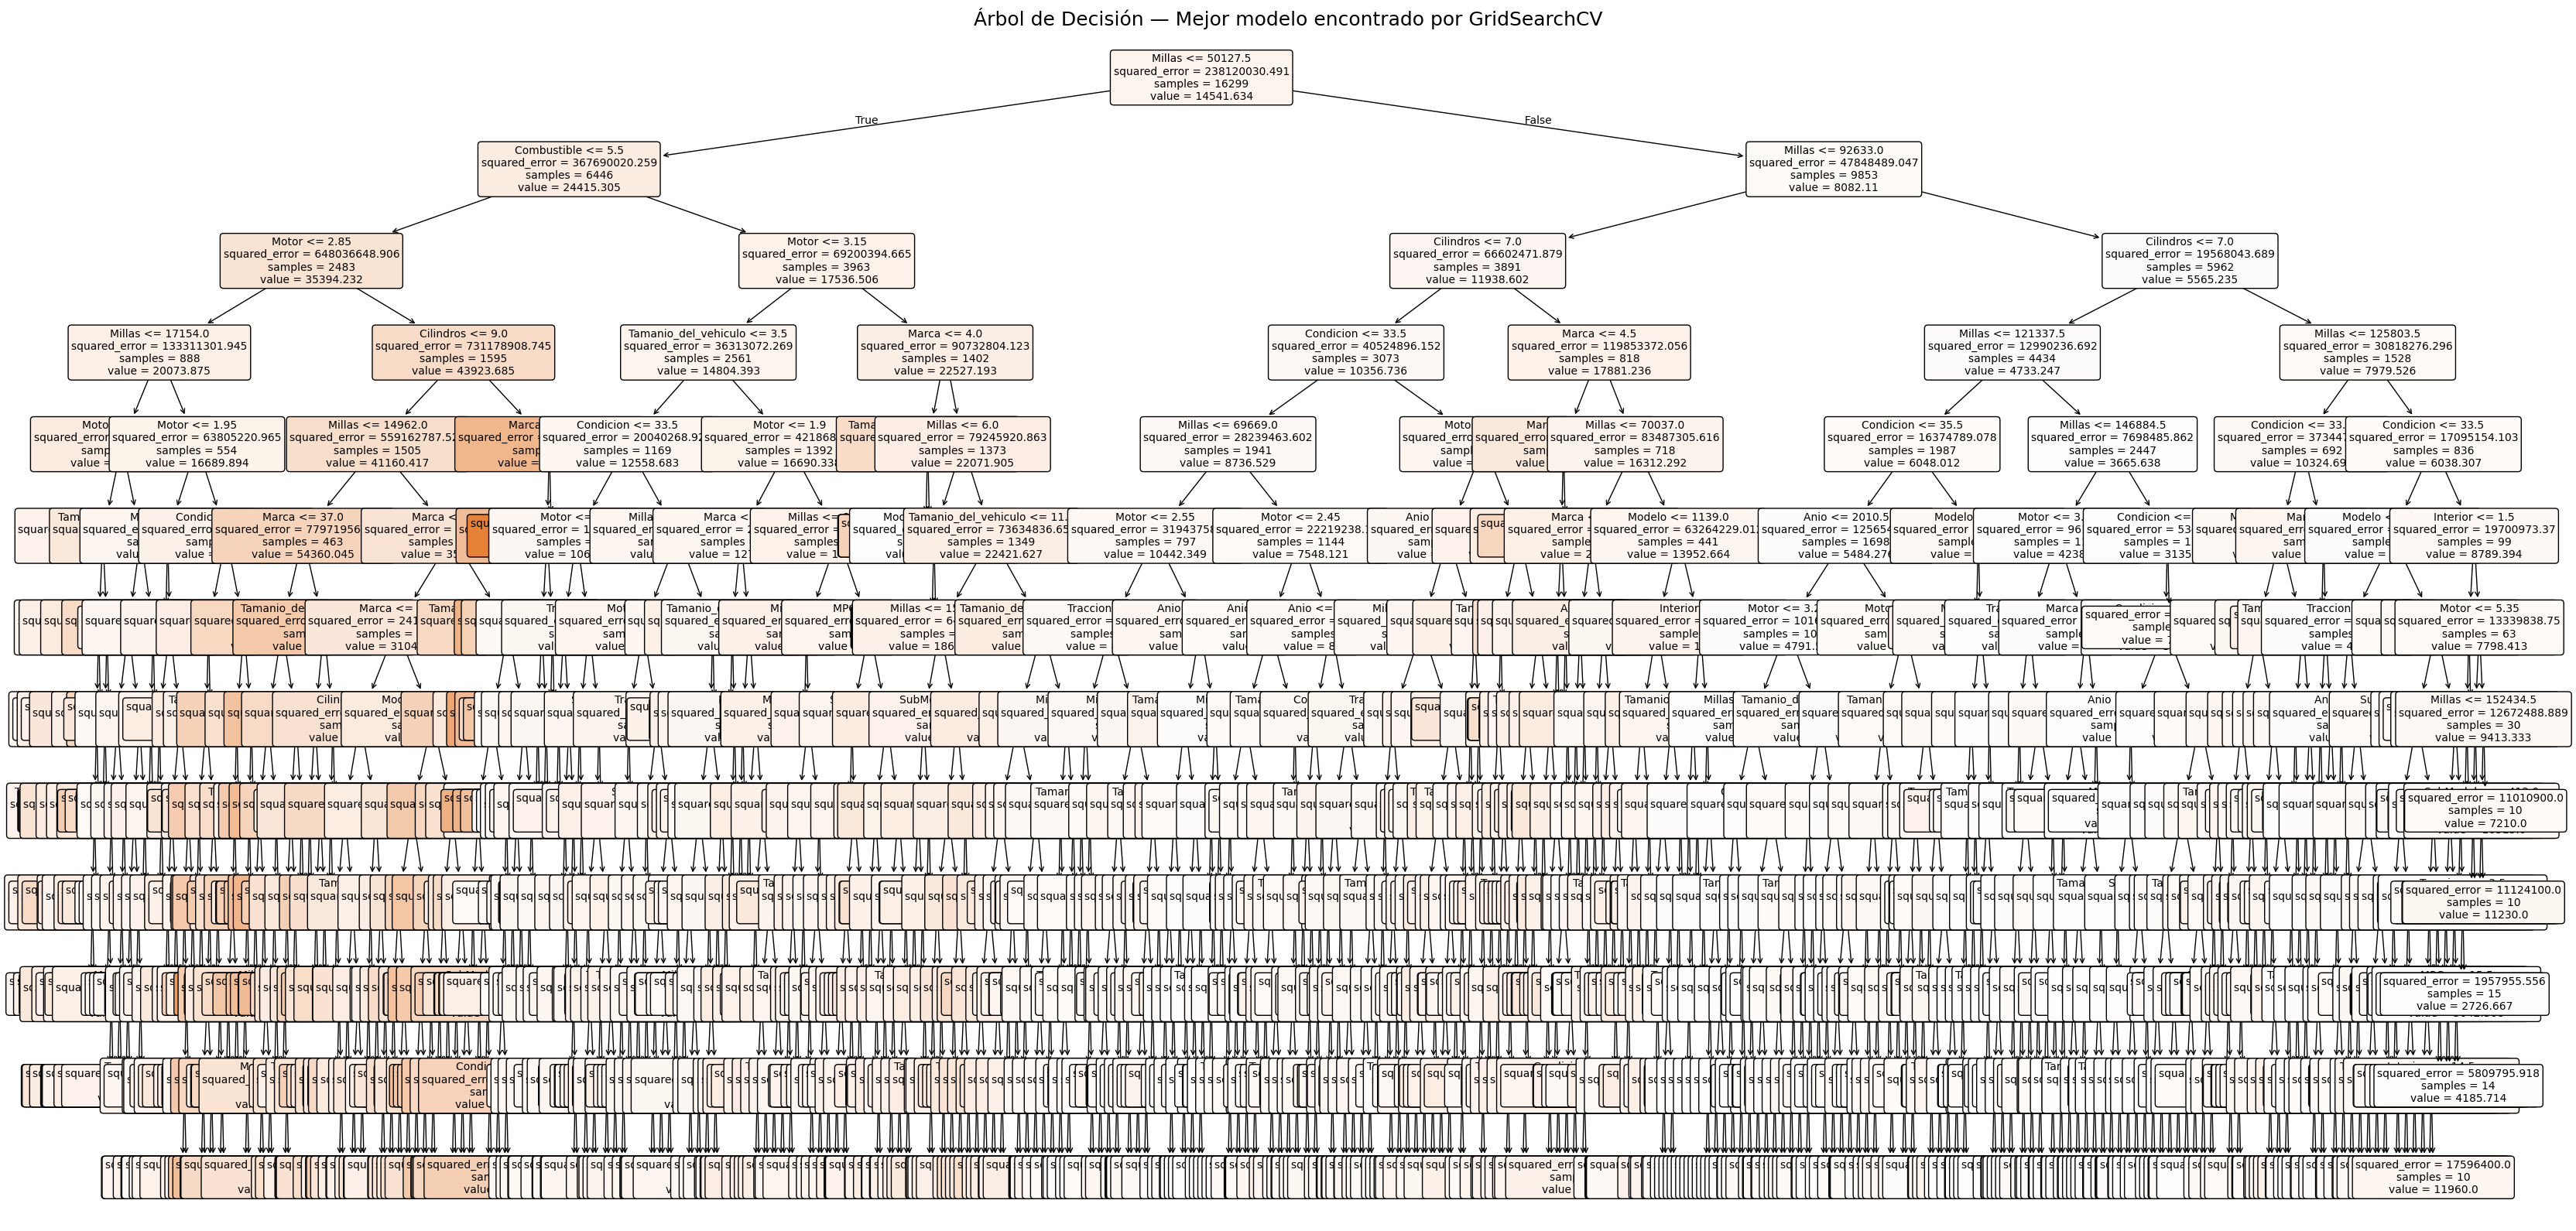

In [15]:
# Accedemos al mejor árbol obtenido por GridSearchCV
best_tree = grid.best_estimator_

plt.figure(figsize=(40, 20))
plot_tree(
    best_tree,
    feature_names=predictors,   # tus variables predictoras
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión — Mejor modelo encontrado por GridSearchCV", fontsize=18)
plt.show()

In [16]:
# Predicciones
y_pred_train_opt = mejor_modelo.predict(X_train)
y_pred_test_opt = mejor_modelo.predict(X_test)


In [17]:
print("MEJOR MODELO:")
print("\nTRAIN")

print(f"  RMSE:     ${np.sqrt(mean_squared_error(y_train, y_pred_train_opt)):.2f}")
print(f"  MAE:      ${mean_absolute_error(y_train, y_pred_train_opt):.2f}")
print(f"  R2:      {r2_score(y_train, y_pred_train_opt):.2f}")

print("\nTEST:")

print(f"  RMSE:     ${np.sqrt(mean_squared_error(y_test, y_pred_test_opt)):.2f}")
print(f"  MAE:      ${mean_absolute_error(y_test, y_pred_test_opt):.2f}")
print(f"  R2:      {r2_score(y_test,  y_pred_test_opt):.2f}")

MEJOR MODELO:

TRAIN
  RMSE:     $5525.07
  MAE:      $3265.14
  R2:      0.87

TEST:
  RMSE:     $7924.57
  MAE:      $4562.40
  R2:      0.73


vemos que los datos mejoran bastante y que amuentado los parametros el arbol va sobre aprendiendo

Entrenando: Base_Tree ...
Entrenando: GridTop1 (depth=12, leaf=10, split=10) ...
Entrenando: GridTop2 (depth=12, leaf=10, split=11) ...
Entrenando: GridTop3 (depth=12, leaf=10, split=7) ...
Entrenando: GridTop4 (depth=12, leaf=10, split=17) ...

Tabla Comparativa de los árboles con los 4 mejores parámetros


,modelo,rmse_train,rmse_test,mae_train,mae_test,r2_train,r2_test
1,"GridTop1 (depth=12, leaf=10, split=10)",5525.067548,7924.574458,3265.14411,4562.396542,0.871803,0.731371
2,"GridTop2 (depth=12, leaf=10, split=11)",5525.067548,7924.574458,3265.14411,4562.396542,0.871803,0.731371
3,"GridTop3 (depth=12, leaf=10, split=7)",5525.067548,7924.574458,3265.14411,4562.396542,0.871803,0.731371
4,"GridTop4 (depth=12, leaf=10, split=17)",5525.067548,7924.574458,3265.14411,4562.396542,0.871803,0.731371
0,Base_Tree,0.000000,9525.641959,0.00000,5389.685228,1.000000,0.611858


1) Bar chart RMSE (train vs test)


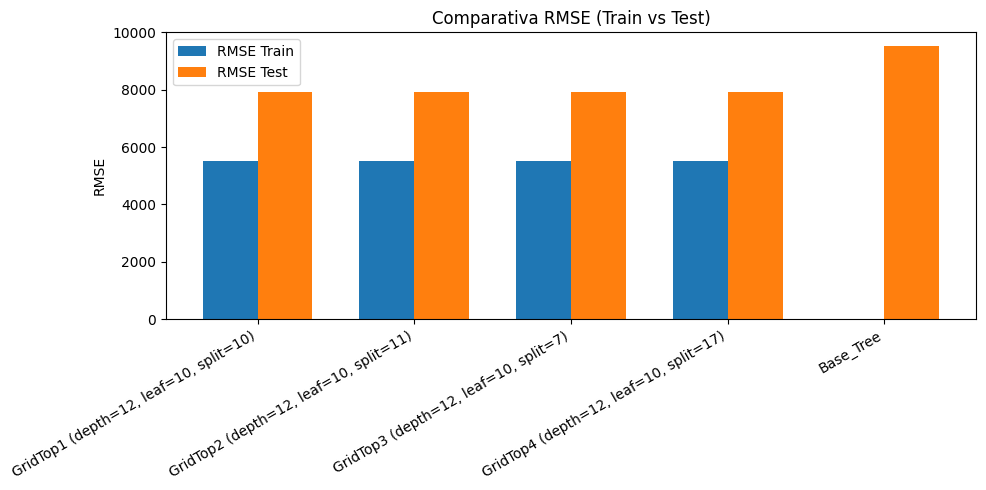

2) Bar chart R2 (train vs test)


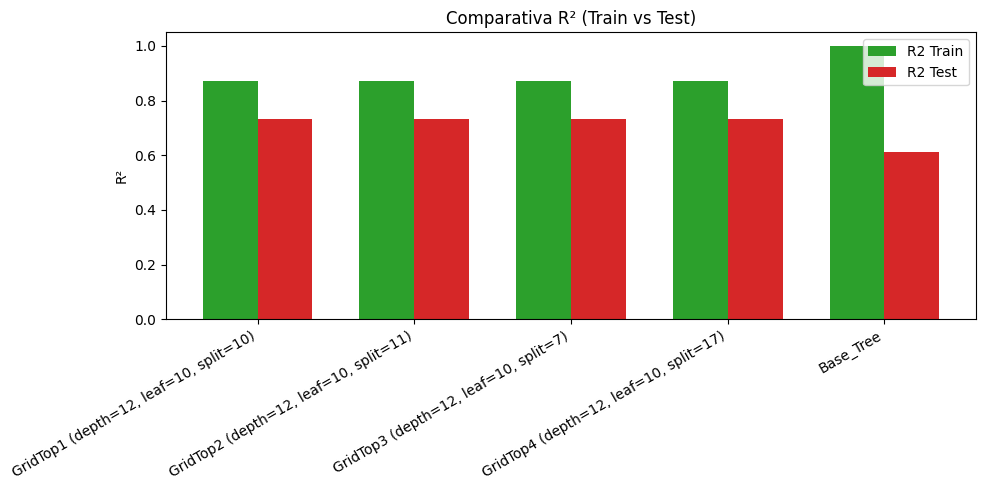

3) Predicho vs Real (test) — varios subplots


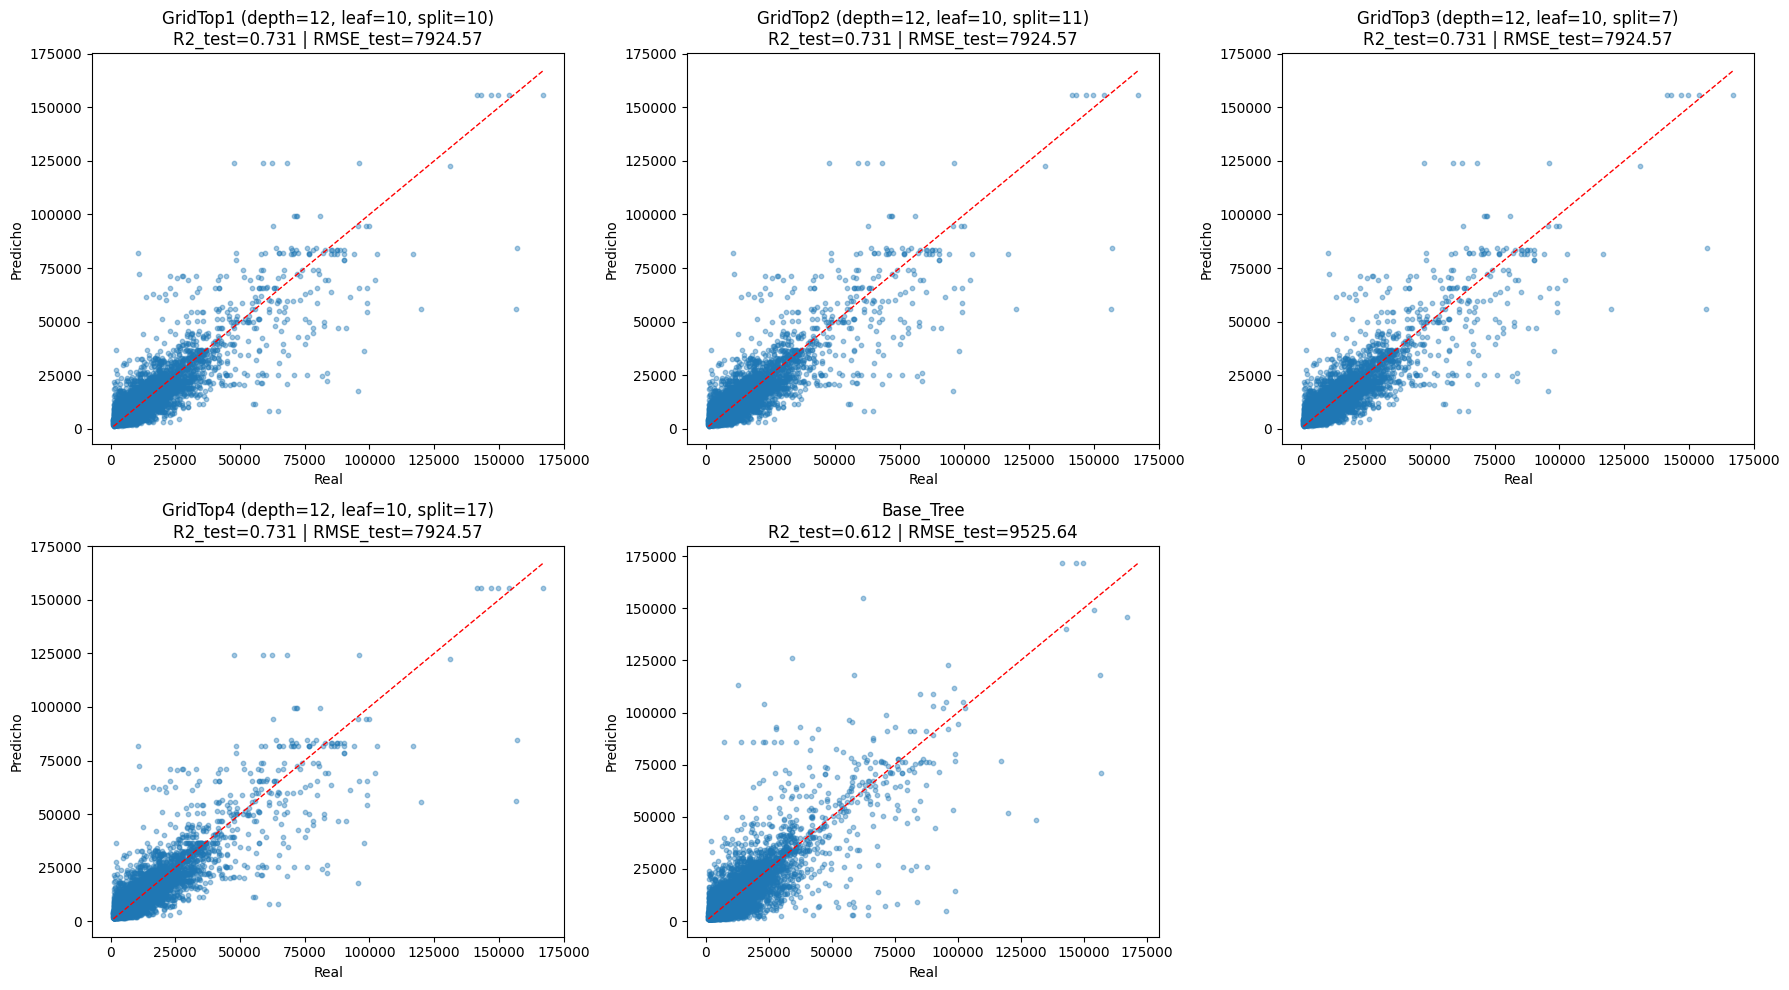

4) Curvas CDF (error absoluto acumulado) — comparar modelos


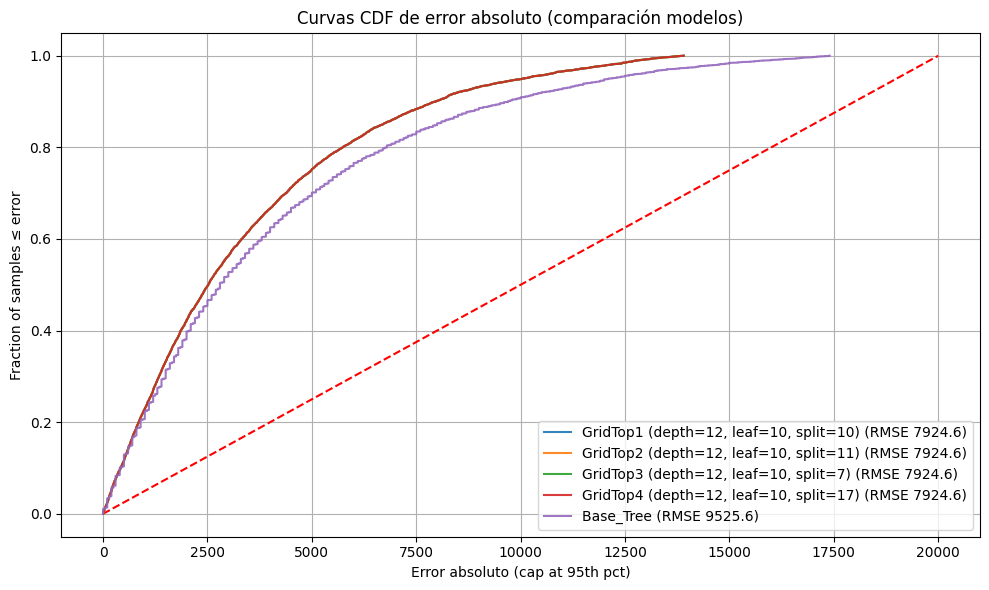

In [22]:
# -- parámetros
top_k = 4

# -- asegurar que y_train/y_test son Series 1D
y_train_s = y_train.squeeze()
y_test_s = y_test.squeeze()

# -- obtener resultados del grid
cvres = grid.cv_results_
mean_scores = np.array(cvres['mean_test_score'])   # en tu setup son neg_mean_squared_error (mayor es mejor)
# orden descendente (mejor primero)
idxs_top = np.argsort(mean_scores)[::-1][:top_k]

# preparar lista de modelos: primero el árbol base (sin restricciones) luego los top_k
models = []
names = []

# árbol base
base = DecisionTreeRegressor(random_state=42)
models.append(base)
names.append('Base_Tree')

# árboles top-K desde grid
for i, idx in enumerate(idxs_top, start=1):
    params = cvres['params'][idx]
    # crear estimator con los parámetros encontrados
    m = DecisionTreeRegressor(random_state=42, **params)
    models.append(m)
    # nombre legible
    names.append(f'GridTop{i} (depth={params.get("max_depth")}, leaf={params.get("min_samples_leaf")}, split={params.get("min_samples_split")})')

# entrenar y evaluar cada modelo
results = []
preds_test = {}
preds_train = {}

for name, model in zip(names, models):
    print(f"Entrenando: {name} ...")
    model.fit(X_train, y_train_s)
    # predicciones
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)
    preds_train[name] = y_pred_tr
    preds_test[name] = y_pred_te

    # métricas
    mae_tr = mean_absolute_error(y_train_s, y_pred_tr)
    mae_te = mean_absolute_error(y_test_s, y_pred_te)
    rmse_tr = np.sqrt(mean_squared_error(y_train_s, y_pred_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test_s, y_pred_te))
    r2_tr = r2_score(y_train_s, y_pred_tr)
    r2_te = r2_score(y_test_s, y_pred_te)

    results.append({
        'modelo': name,
        'mae_train': mae_tr, 'mae_test': mae_te,
        'rmse_train': rmse_tr, 'rmse_test': rmse_te,
        'r2_train': r2_tr, 'r2_test': r2_te,
        'params': getattr(model, 'get_params', lambda: {})()
    })

    
print('\n=============================================================')
print('Tabla Comparativa de los árboles con los 4 mejores parámetros')
print('=============================================================')

results_df = pd.DataFrame(results).sort_values('rmse_test')
display(results_df[['modelo','rmse_train','rmse_test','mae_train','mae_test','r2_train','r2_test']])

print('=============================================================')
print('1) Bar chart RMSE (train vs test)')
print('=============================================================')

# Gráficas comparativas
# 1) Bar chart RMSE (train vs test)
plt.figure(figsize=(10,5))
x = np.arange(len(results_df))
width = 0.35
plt.bar(x - width/2, results_df['rmse_train'], width, label='RMSE Train', color='tab:blue')
plt.bar(x + width/2, results_df['rmse_test'], width, label='RMSE Test', color='tab:orange')
plt.xticks(x, results_df['modelo'], rotation=30, ha='right')
plt.ylabel('RMSE')
plt.title('Comparativa RMSE (Train vs Test)')
plt.legend()
plt.tight_layout()
plt.show()

print('=============================================================')
print('2) Bar chart R2 (train vs test)')
print('=============================================================')


# 2) Bar chart R2 (train vs test)
plt.figure(figsize=(10,5))
plt.bar(x - width/2, results_df['r2_train'], width, label='R2 Train', color='tab:green')
plt.bar(x + width/2, results_df['r2_test'], width, label='R2 Test', color='tab:red')
plt.xticks(x, results_df['modelo'], rotation=30, ha='right')
plt.ylabel('R²')
plt.title('Comparativa R² (Train vs Test)')
plt.legend()
plt.tight_layout()
plt.show()

print('=============================================================')
print('3) Predicho vs Real (test) — varios subplots')
print('=============================================================')


# 3) Predicho vs Real (test) — varios subplots
n_models = len(results_df)
ncols = 3
nrows = int(np.ceil(n_models / ncols))
plt.figure(figsize=(6*ncols, 5*nrows))

for i, row in enumerate(results_df.itertuples(), start=1):
    name = row.modelo
    y_pred = preds_test[name]
    plt.subplot(nrows, ncols, i)
    # para no saturar, muestreamos hasta 5000 puntos si hay muchos
    N = len(y_test_s)
    sample_idx = np.arange(N)
    if N > 5000:
        np.random.seed(42)
        sample_idx = np.random.choice(N, 5000, replace=False)
    plt.scatter(y_test_s.iloc[sample_idx], y_pred[sample_idx], alpha=0.4, s=10)
    minv = min(y_test_s.min(), y_pred.min())
    maxv = max(y_test_s.max(), y_pred.max())
    plt.plot([minv, maxv], [minv, maxv], 'r--', lw=1)
    plt.xlabel('Real')
    plt.ylabel('Predicho')
    plt.title(f'{name}\nR2_test={row.r2_test:.3f} | RMSE_test={row.rmse_test:.2f}')
plt.tight_layout()
plt.show()

print('=============================================================')
print('4) Curvas CDF (error absoluto acumulado) — comparar modelos')
print('=============================================================')

# 4) Curvas CDF (error absoluto acumulado) — comparar modelos
plt.figure(figsize=(10,6))
pctl = 95   # hasta percentil 95 para evitar cola extrema
plt.plot([0, 20000], [0, 1], linestyle='--', color='red')
for row in results_df.itertuples():
    name = row.modelo
    errs = np.abs(y_test_s.values - preds_test[name])
    # limitar al percentil pctl para comparar más claramente
    cap = np.percentile(errs, pctl)
    xs = np.sort(errs)
    xs = xs[xs <= cap]
    cdf = np.arange(1, len(xs)+1) / len(xs)
    plt.plot(xs, cdf, label=f'{name} (RMSE {row.rmse_test:.1f})', alpha=0.9)

plt.xlabel('Error absoluto (cap at 95th pct)')
plt.ylabel('Fraction of samples ≤ error')
plt.title('Curvas CDF de error absoluto (comparación modelos)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
